# Qiskit Example: Modeling $\textrm{H}_2$ using VQE

This notebook computes the ground-state energy of $\textrm{H}_2$ with the
Variational Quantum Eigensolver, built entirely from scratch: PySCF
integrals in a block-spin spin-orbital basis, analytic Jordan-Wigner Pauli
algebra, a generic Pauli-exponential circuit primitive, and two different
ansätze built on top of it. It runs the same closed-loop VQE optimization
along three independent axes, changing one at a time so that every
comparison isolates a single cause rather than mixing several:

1. **ansatz** -- a chemistry-informed **UCCSD** circuit (3 parameters for
   $\textrm{H}_2$, built from the Trotterized excitation operators derived
   below) vs. a **hardware-efficient ansatz** (12 parameters, just
   rotations and a CNOT ladder, encoding no chemistry at all);
2. **energy evaluation** -- an **exact** simulator (no sampling, no noise)
   vs. a **noisy simulator built from a real IBM quantum processor's live
   calibration data** -- its measured per-qubit coherence times, gate
   error rates, readout confusion matrices, coupling map and native gate
   set -- evaluated with an explicit number of measurement shots;
3. **optimizer** -- **COBYLA** (`scipy.optimize`) vs. **SPSA**
   (`qiskit_algorithms.optimizers`, the noise-aware optimizer standard
   throughout the VQE literature), run on the noisy simulator for both
   ansätze.

Because only one axis changes between any two runs being compared, the gap
between their results is attributable to that one change, not to several
at once. Nothing is ever submitted to hardware: only calibration data is
downloaded, and every circuit -- exact or noisy -- runs locally in Aer.
The exact FCI energy is shown alongside every VQE result purely as a
reference point for judging how close each configuration gets, not as a
pass/fail check.

## 0. Setup

In [63]:

import numpy as np
from itertools import combinations
%matplotlib inline
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

print("NumPy version:", np.__version__)
import pyscf
print("PySCF version:", pyscf.__version__)
import qiskit
print("Qiskit version:", qiskit.__version__)
import qiskit_aer
print("Qiskit Aer version:", qiskit_aer.__version__)
import qiskit_ibm_runtime
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)
import qiskit_algorithms
print("Qiskit Algorithms version:", qiskit_algorithms.__version__)


NumPy version: 2.5.3
PySCF version: 2.14.0
Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Qiskit IBM Runtime version: 0.49.0
Qiskit Algorithms version: 0.4.0



## 1. Build the $\textrm{H}_2$ molecule and run Hartree-Fock

STO-3G (2 spatial orbitals, 4 spin-orbitals = 4 qubits) at the experimental
equilibrium bond length 0.7414 Å.


In [64]:

from pyscf import gto, scf

mol = gto.M(atom='H 0 0 0; H 0 0 0.7414', basis='sto-3g', unit='Angstrom', verbose=0)
mf = scf.RHF(mol).run()

print(f"Molecule: H2, bond length 0.7414 Angstrom, basis STO-3G")
print(f"Number of electrons: {mol.nelectron}")
print(f"Number of spatial molecular orbitals: {mf.mo_coeff.shape[1]}")
print(f"Number of spin-orbitals (qubits needed): {2 * mf.mo_coeff.shape[1]}")
print(f"RHF total energy = {mf.e_tot:.8f} Hartree")


Molecule: H2, bond length 0.7414 Angstrom, basis STO-3G
Number of electrons: 2
Number of spatial molecular orbitals: 2
Number of spin-orbitals (qubits needed): 4
RHF total energy = -1.11668439 Hartree



## 2. Extract spin-orbital integrals (block-spin ordering)

Spin-orbital index $P = \sigma \cdot n_{\text{mo}} + p_{\text{spatial}}$
(spin $\sigma=0$ alpha, $\sigma=1$ beta) -- qubits $0,1$ are the $\alpha$
copies of spatial orbitals $0,1$, qubits $2,3$ their $\beta$ copies. This
matches Qiskit Nature's default qubit layout.


In [65]:

from pyscf import ao2mo

def extract_spinorbital_integrals(mol, mf):
    E_nuc = mol.energy_nuc()
    C = mf.mo_coeff
    n_mo = C.shape[1]

    h_core_AO = mf.get_hcore()
    h_core_MO = C.T @ h_core_AO @ C

    eri_AO = mol.intor('int2e_sph', aosym='s8')
    eri_spatial = ao2mo.incore.general(eri_AO, (C, C, C, C), compact=False).reshape(n_mo, n_mo, n_mo, n_mo)

    n_so = 2 * n_mo
    def spin_idx(p, spin):
        return spin * n_mo + p

    h1 = np.zeros((n_so, n_so))
    for p in range(n_mo):
        for q in range(n_mo):
            h1[spin_idx(p, 0), spin_idx(q, 0)] = h_core_MO[p, q]
            h1[spin_idx(p, 1), spin_idx(q, 1)] = h_core_MO[p, q]

    h2 = np.zeros((n_so, n_so, n_so, n_so))
    for sp in (0, 1):
        for sq in (0, 1):
            for p in range(n_mo):
                for q in range(n_mo):
                    for r in range(n_mo):
                        for s in range(n_mo):
                            h2[spin_idx(p, sp), spin_idx(q, sp),
                               spin_idx(r, sq), spin_idx(s, sq)] = eri_spatial[p, q, r, s]

    return h1, h2, E_nuc, n_mo

h1, h2, E_nuc, n_mo = extract_spinorbital_integrals(mol, mf)
n_so = h1.shape[0]

print(f"h1 shape: {h1.shape}   h2 shape: {h2.shape}")
print(f"E_nuc = {E_nuc:.8f} Hartree")
print(f"number of nonzero h2 entries: {np.count_nonzero(np.abs(h2) > 1e-10)} out of {n_so**4}")


h1 shape: (4, 4)   h2 shape: (4, 4, 4, 4)
E_nuc = 0.71375399 Hartree
number of nonzero h2 entries: 32 out of 256



## 3. Symbolic Pauli algebra

Operators are represented as dicts `{pauli_label: coefficient}` and
multiplied/added symbolically -- no $2^n\times2^n$ matrices anywhere in
this notebook.


In [66]:

_MULT = {
    ('I', 'I'): (1, 'I'), ('I', 'X'): (1, 'X'), ('I', 'Y'): (1, 'Y'), ('I', 'Z'): (1, 'Z'),
    ('X', 'I'): (1, 'X'), ('Y', 'I'): (1, 'Y'), ('Z', 'I'): (1, 'Z'),
    ('X', 'X'): (1, 'I'), ('Y', 'Y'): (1, 'I'), ('Z', 'Z'): (1, 'I'),
    ('X', 'Y'): (1j, 'Z'), ('Y', 'X'): (-1j, 'Z'),
    ('Y', 'Z'): (1j, 'X'), ('Z', 'Y'): (-1j, 'X'),
    ('Z', 'X'): (1j, 'Y'), ('X', 'Z'): (-1j, 'Y'),
}

def multiply_pauli_strings(label1, label2):
    phase = 1
    result = []
    for c1, c2 in zip(label1, label2):
        p, c = _MULT[(c1, c2)]
        phase *= p
        result.append(c)
    return phase, ''.join(result)

def multiply_pauli_sums(sum1, sum2, tol=1e-12):
    result = {}
    for label1, c1 in sum1.items():
        for label2, c2 in sum2.items():
            phase, label = multiply_pauli_strings(label1, label2)
            result[label] = result.get(label, 0) + c1 * c2 * phase
    return {k: v for k, v in result.items() if abs(v) > tol}

def scale_pauli_sum(sum1, factor):
    return {k: v * factor for k, v in sum1.items()}

def add_pauli_sums(*sums, tol=1e-12):
    result = {}
    for s in sums:
        for label, c in s.items():
            result[label] = result.get(label, 0) + c
    return {k: v for k, v in result.items() if abs(v) > tol}

print("Pauli algebra primitives defined: multiply_pauli_strings, multiply_pauli_sums,")
print("scale_pauli_sum, add_pauli_sums")


Pauli algebra primitives defined: multiply_pauli_strings, multiply_pauli_sums,
scale_pauli_sum, add_pauli_sums



## 4. Jordan-Wigner creation/annihilation operators

$$a_p = Z_0 \cdots Z_{p-1} \frac{X_p + iY_p}{2} I \cdots I \qquad
  a_p^\dagger = Z_0 \cdots Z_{p-1} \frac{X_p - iY_p}{2} I \cdots I$$


In [67]:

def jw_annihilation(p, n):
    prefix = 'Z' * p
    suffix = 'I' * (n - p - 1)
    return {prefix + 'X' + suffix: 0.5, prefix + 'Y' + suffix: 0.5j}

def jw_creation(p, n):
    prefix = 'Z' * p
    suffix = 'I' * (n - p - 1)
    return {prefix + 'X' + suffix: 0.5, prefix + 'Y' + suffix: -0.5j}

print("a_0 (n=4 qubits):     ", jw_annihilation(0, 4))
print("a_2^dagger (n=4 qubits):", jw_creation(2, 4))


a_0 (n=4 qubits):      {'XIII': 0.5, 'YIII': 0.5j}
a_2^dagger (n=4 qubits): {'ZZXI': 0.5, 'ZZYI': (-0-0.5j)}



## 5. Build the qubit Hamiltonian

$$H = \sum_{pq} h_1[p,q]\, a_p^\dagger a_q \;+\; \tfrac12 \sum_{pqrs} h_2[p,q,r,s]\, a_p^\dagger a_r^\dagger a_s a_q \;+\; E_{\text{nuc}}$$


In [68]:

def build_qubit_hamiltonian_pauli(h1, h2, E_nuc, tol=1e-10):
    n = h1.shape[0]
    a = [jw_annihilation(p, n) for p in range(n)]
    ad = [jw_creation(p, n) for p in range(n)]

    H = {}
    for p in range(n):
        for q in range(n):
            if abs(h1[p, q]) < tol:
                continue
            term = multiply_pauli_sums(ad[p], a[q])
            H = add_pauli_sums(H, scale_pauli_sum(term, h1[p, q]))

    for p in range(n):
        for q in range(n):
            for r in range(n):
                for s in range(n):
                    if abs(h2[p, q, r, s]) < tol:
                        continue
                    left = multiply_pauli_sums(ad[p], ad[r])
                    right = multiply_pauli_sums(a[s], a[q])
                    term = multiply_pauli_sums(left, right)
                    H = add_pauli_sums(H, scale_pauli_sum(term, 0.5 * h2[p, q, r, s]))

    H = add_pauli_sums(H, {'I' * n: E_nuc})

    H_clean = {}
    for k, v in H.items():
        if abs(v) > tol:
            H_clean[k] = v.real
    return H_clean

H_pauli = build_qubit_hamiltonian_pauli(h1, h2, E_nuc)
print(f"Qubit Hamiltonian: {len(H_pauli)} nonzero Pauli terms\n")
for label, coeff in sorted(H_pauli.items(), key=lambda x: -abs(x[1])):
    print(f"  {label} : {coeff:+.8f}")

from pyscf import fci
e_fci, _ = fci.FCI(mf).kernel()
print(f"\n(for reference: PySCF FCI ground-state energy = {e_fci:.8f} Hartree)")


Qubit Hamiltonian: 15 nonzero Pauli terms

  IIIZ : -0.22278593
  IZII : -0.22278593
  IZIZ : +0.17434844
  IIZI : +0.17119775
  ZIII : +0.17119775
  ZIZI : +0.16862219
  ZIIZ : +0.16586702
  IZZI : +0.16586702
  ZZII : +0.12054482
  IIZZ : +0.12054482
  IIII : -0.09886397
  YYYY : +0.04532220
  YYXX : +0.04532220
  XXYY : +0.04532220
  XXXX : +0.04532220

(for reference: PySCF FCI ground-state energy = -1.13727017 Hartree)



## 6. UCC excitation operators

$$T_1(p,q) = a_p^\dagger a_q - a_q^\dagger a_p \qquad (p \text{ virtual}, q \text{ occupied})$$
$$T_2(p,q,r,s) = a_p^\dagger a_q^\dagger a_r a_s - a_s^\dagger a_r^\dagger a_q a_p \qquad (p{>}q \text{ virtual}, r{>}s \text{ occupied})$$

For $\textrm{H}_2$ under block-spin ordering, occupied = $\{0,2\}$ (the $\alpha,\beta$
copies of spatial orbital 0), virtual = $\{1,3\}$: 2 same-spin singles and
1 double excitation.


In [69]:

def single_excitation_pauli(p, q, n, tol=1e-10):
    term1 = multiply_pauli_sums(jw_creation(p, n), jw_annihilation(q, n))
    term2 = multiply_pauli_sums(jw_creation(q, n), jw_annihilation(p, n))
    T = add_pauli_sums(term1, scale_pauli_sum(term2, -1.0), tol=tol)
    return {k: v for k, v in T.items() if abs(v) > tol}

def double_excitation_pauli(p, q, r, s, n, tol=1e-10):
    left1 = multiply_pauli_sums(jw_creation(p, n), jw_creation(q, n))
    right1 = multiply_pauli_sums(jw_annihilation(r, n), jw_annihilation(s, n))
    term1 = multiply_pauli_sums(left1, right1)

    left2 = multiply_pauli_sums(jw_creation(s, n), jw_creation(r, n))
    right2 = multiply_pauli_sums(jw_annihilation(q, n), jw_annihilation(p, n))
    term2 = multiply_pauli_sums(left2, right2)

    T = add_pauli_sums(term1, scale_pauli_sum(term2, -1.0), tol=tol)
    return {k: v for k, v in T.items() if abs(v) > tol}

def generate_excitations(occ, n_so):
    occ = sorted(occ)
    virt = sorted(set(range(n_so)) - set(occ))
    n_spatial = n_so // 2
    spin = lambda idx: idx // n_spatial  # block-spin: 0..n_spatial-1 alpha, rest beta
    excitations = []
    for q in occ:
        for p in virt:
            if spin(p) == spin(q):
                excitations.append({'type': 'single', 'indices': (p, q)})
    for r, s in combinations(occ, 2):
        r, s = max(r, s), min(r, s)
        for p, q in combinations(virt, 2):
            p, q = max(p, q), min(p, q)
            if sorted((spin(p), spin(q))) == sorted((spin(r), spin(s))):
                excitations.append({'type': 'double', 'indices': (p, q, r, s)})
    return excitations

occ = [0, 2]  # block-spin: alpha and beta copies of spatial orbital 0
excitations = generate_excitations(occ, n_so)
print(f"H2 excitation pool ({len(excitations)} excitations):")
for exc in excitations:
    print(f"  {exc}")


H2 excitation pool (3 excitations):
  {'type': 'single', 'indices': (1, 0)}
  {'type': 'single', 'indices': (3, 2)}
  {'type': 'double', 'indices': (3, 1, 2, 0)}



## 7. Circuit primitive: $\exp(i\varphi \cdot \text{PauliString})$

Basis-rotate every non-identity qubit into the $Z$ basis, CNOT-stair to
accumulate parity onto the last active qubit, apply $R_z$ there, then undo
both.


example block: exp(i*0.37*XXXY)


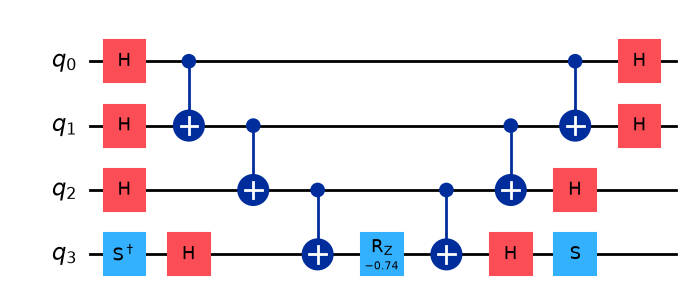

In [70]:

from qiskit import QuantumCircuit

def add_pauli_exp_block(qc, pauli_label, phi):
    active = [q for q, c in enumerate(pauli_label) if c != 'I']
    if not active:
        return
    for q in active:
        c = pauli_label[q]
        if c == 'X':
            qc.h(q)
        elif c == 'Y':
            qc.sdg(q); qc.h(q)
    for k in range(len(active) - 1):
        qc.cx(active[k], active[k + 1])
    qc.rz(-2 * phi, active[-1])
    for k in reversed(range(len(active) - 1)):
        qc.cx(active[k], active[k + 1])
    for q in active:
        c = pauli_label[q]
        if c == 'X':
            qc.h(q)
        elif c == 'Y':
            qc.h(q); qc.s(q)

qc_demo = QuantumCircuit(4)
add_pauli_exp_block(qc_demo, 'XXXY', 0.37)
print("example block: exp(i*0.37*XXXY)")
fig_demo = qc_demo.draw('mpl')
display(fig_demo)
plt.close(fig_demo)   # avoid a second, automatic render from the inline backend



## 8. Assemble the full UCCSD ansatz circuit

$X$ gates on the occupied qubits (0, 2) prepare $|\text{HF}\rangle$, then
one Trotter step of every excitation in the pool, each with its own
variational `Parameter`.


UCCSD circuit for H2: 4 qubits, 3 variational parameters
circuit depth: 110, total gate count: 190



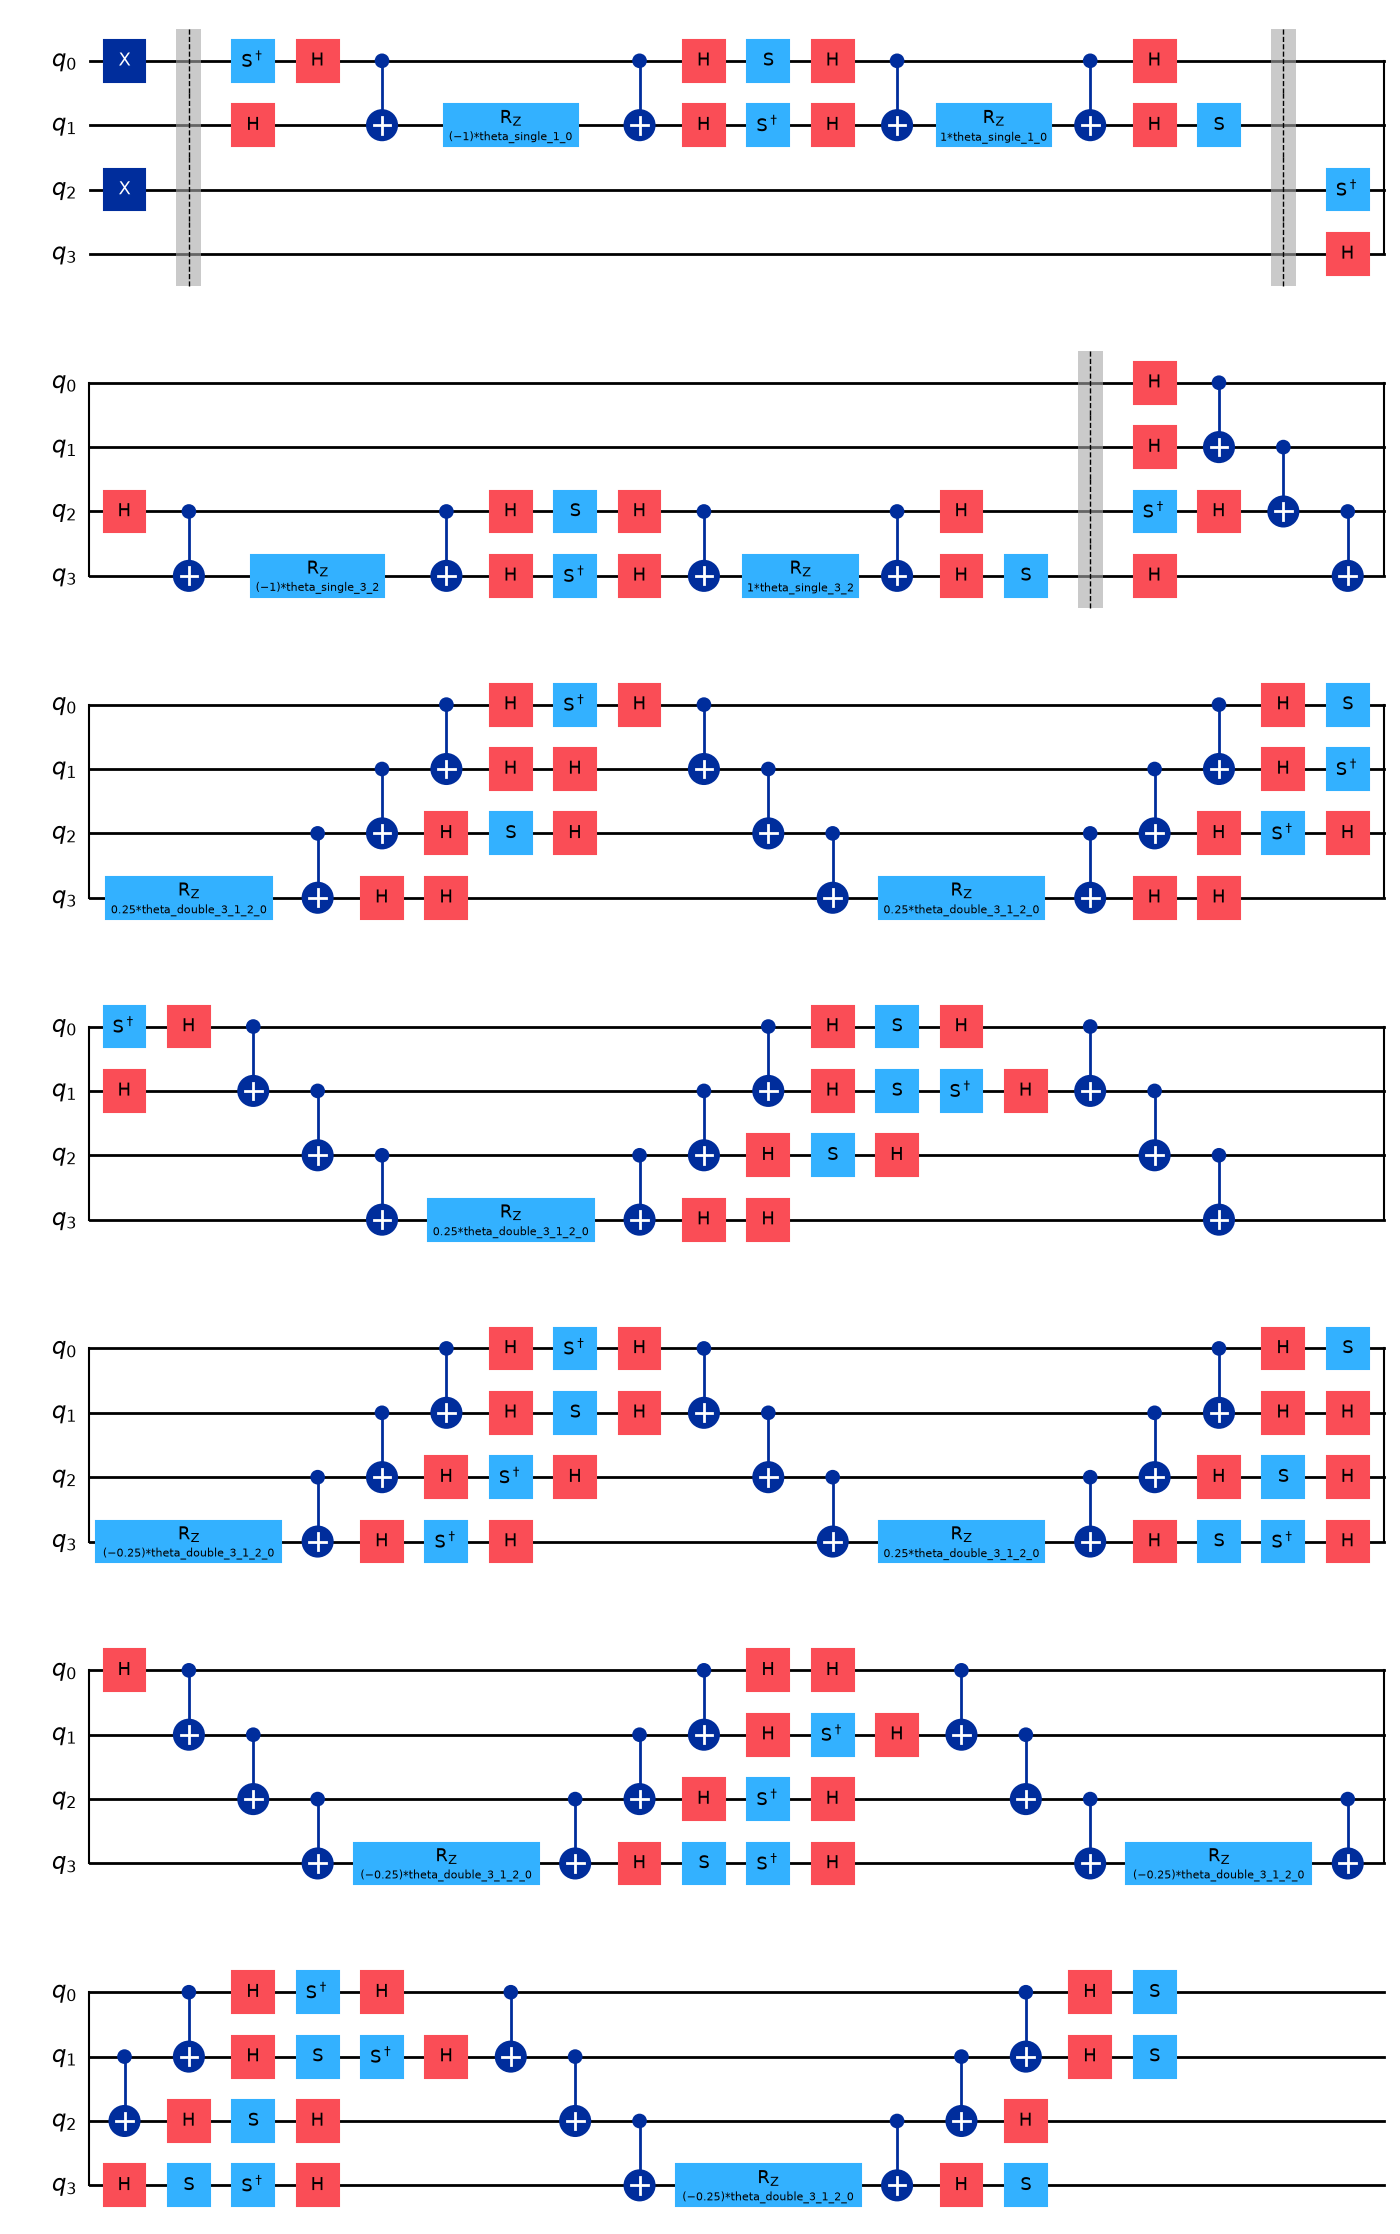

In [71]:

from qiskit.circuit import Parameter

def build_uccsd_ansatz(n_so, occ, tol=1e-10):
    occ = sorted(occ)
    excitations = generate_excitations(occ, n_so)
    qc = QuantumCircuit(n_so, name='UCCSD')
    for i in occ:
        qc.x(i)

    params = []
    for exc in excitations:
        theta = Parameter(f"theta_{exc['type']}_{'_'.join(map(str, exc['indices']))}")
        params.append(theta)
        if exc['type'] == 'single':
            p, q = exc['indices']
            pdict = single_excitation_pauli(p, q, n_so, tol=tol)
        else:
            p, q, r, s = exc['indices']
            pdict = double_excitation_pauli(p, q, r, s, n_so, tol=tol)
        qc.barrier()
        for label, coeff in pdict.items():
            w = coeff.imag
            add_pauli_exp_block(qc, label, theta * w)

    return qc, excitations, params

qc_uccsd, excitations, params = build_uccsd_ansatz(n_so, occ)
print(f"UCCSD circuit for H2: {qc_uccsd.num_qubits} qubits, {len(params)} variational parameters")
print(f"circuit depth: {qc_uccsd.depth()}, total gate count: {qc_uccsd.size()}\n")
fig_uccsd = qc_uccsd.draw('mpl', fold=20)
display(fig_uccsd)
plt.close(fig_uccsd)   # avoid a second, automatic render from the inline backend



## 9. VQE on an exact simulator -- the noiseless baseline

Before introducing any hardware imperfection, run the same VQE loop
against an **exact** evaluation of the energy. This establishes what the
ansatz and the optimizer can achieve when nothing goes wrong, and it is the
number every later, noisier result should be measured against.

"Exact" is meant literally here. The energy comes from
`Statevector.expectation_value`, which contracts the full state vector
against the Hamiltonian analytically: no sampling, no shot count, no noise
channel. Evaluate the same parameters twice and you get the same digits
back. For $\textrm{H}_2$'s 4 qubits that costs nothing, and it is the only regime in
which we get to see how the ansatz is *supposed* to behave.

A correct UCCSD ansatz should recover the FCI energy to essentially machine
precision, because for $\textrm{H}_2$ the single double-excitation spans the entire
correlation problem.


In [72]:

from qiskit.quantum_info import Statevector, SparsePauliOp
from scipy.optimize import minimize

# SparsePauliOp uses Qiskit's own string convention (leftmost char = highest
# qubit index), the opposite of this notebook's label convention
# (label[0] = qubit 0) -- reverse each label when handing it to Qiskit.
observable = SparsePauliOp.from_list([(label[::-1], coeff) for label, coeff in H_pauli.items()])
print(f"observable: {len(observable)}-term SparsePauliOp\n")

history_exact = []

def energy_exact(theta):
    bound = qc_uccsd.assign_parameters(dict(zip(params, theta)))
    E = float(np.real(Statevector.from_instruction(bound).expectation_value(observable)))
    history_exact.append(E)
    return E

x0 = np.zeros(len(params))   # start from the bare HF state
result_exact = minimize(energy_exact, x0, method='COBYLA',
                        options={'maxiter': 250, 'rhobeg': 0.25})

corr_total = mf.e_tot - e_fci
corr_found = mf.e_tot - result_exact.fun
print(f"exact VQE finished after {len(history_exact)} energy evaluations")
print(f"exact VQE minimum = {result_exact.fun:.8f} Hartree")
print(f"PySCF FCI (exact) = {e_fci:.8f} Hartree")
print(f"PySCF RHF         = {mf.e_tot:.8f} Hartree")
print(f"error vs FCI      = {result_exact.fun - e_fci:+.3e} Hartree")
print(f"correlation energy recovered: {corr_found:.8f} of {corr_total:.8f} Ha "
      f"({100*corr_found/corr_total:.3f}%)")
print()
print("optimal parameters found:")
for p, v in zip(params, result_exact.x):
    print(f"  {p.name} = {v:+.8f}")


observable: 15-term SparsePauliOp

exact VQE finished after 44 energy evaluations
exact VQE minimum = -1.13727017 Hartree
PySCF FCI (exact) = -1.13727017 Hartree
PySCF RHF         = -1.11668439 Hartree
error vs FCI      = +1.822e-09 Hartree
correlation energy recovered: 0.02058579 of 0.02058579 Ha (100.000%)

optimal parameters found:
  theta_single_1_0 = -0.00003341
  theta_single_3_2 = -0.00000261
  theta_double_3_1_2_0 = +0.11304444



Two things to notice in the output above, both of which will be worth
remembering once noise enters the picture:

- The minimum sits on top of the FCI energy to several decimal places. The
  ansatz is not the limitation for $\textrm{H}_2$; anything we lose later is the
  device's doing, not the algorithm's.
- The two **single**-excitation angles converge to ~0. That is Brillouin's
  theorem: for an RHF reference, singly-excited determinants have zero
  Hamiltonian matrix element with the reference, so VQE correctly finds no
  use for them. All the correlation energy comes from the one double
  excitation.


## 10. Build the noisy simulator from a *real* IBM backend

Rather than inventing error rates, this notebook pulls them from a machine
that actually exists. `QiskitRuntimeService` reads the saved account in
`~/.qiskit/qiskit-ibm.json` and connects to a **fixed, explicitly named
device** (`ibm_kingston`) rather than `service.least_busy(...)`, so that
every run in this notebook -- exact vs. noisy, UCCSD vs. hardware-efficient,
COBYLA vs. SPSA -- is evaluated against the *same* calibration snapshot and
the results can be fairly compared to each other. `least_busy` is
convenient but picks whichever device happens to be idle at the moment the
cell runs, so re-running the notebook can silently swap in a different
processor with different error rates; Section 12's discussion shows how
much that alone can move the results.

`AerSimulator.from_backend(backend)` then builds a simulator carrying that
device's **live calibration**: per-qubit $T_1$/$T_2$, per-gate error rates,
each qubit's individual readout confusion matrix, the heavy-hex coupling
map, and the native basis gates. One call does all of it.

Only calibration data is downloaded -- nothing is ever submitted to
hardware, so this costs no queue time and no money.

> **Prerequisite:** an IBM Quantum account saved under the name used below.
> `QiskitRuntimeService.save_account(channel=..., token=..., name=...)`
> writes it to `~/.qiskit/qiskit-ibm.json`.

In [73]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

ACCOUNT = "ibm-cloud-yahoo"   # name of the saved account in ~/.qiskit/qiskit-ibm.json

service = QiskitRuntimeService(name=ACCOUNT)
backend = service.backend('ibm_kingston')   # fixed device, not least_busy(...) -- see Section 10
sim = AerSimulator.from_backend(backend)

print(f"backend: {backend.name} -- {backend.num_qubits} qubits, "
      f"{backend.status().pending_jobs} job(s) queued")
nm = sim.options.noise_model
print(f"simulator carries its calibration: noise on {len(nm.noise_instructions)} "
      f"instruction types across {len(nm.noise_qubits)} qubits")
print(f"native basis gates: {sorted(g for g in nm.basis_gates)}")

backend: ibm_kingston -- 156 qubits, 0 job(s) queued
simulator carries its calibration: noise on 11 instruction types across 156 qubits
native basis gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'measure_reset', 'measure_reset_2', 'reset', 'reset_2', 'rz', 'sx', 'x', 'xslow']



### 10a. Transpile to the device's instruction set

This step is not optional, and it is where most of the damage happens. The
UCCSD circuit above is written in $H$/$S$/$S^\dagger$/CX. An IBM Heron
device speaks only $R_z$/$\sqrt{X}$/$X$/CZ, on a fixed heavy-hex coupling
map -- so the circuit has to be rewritten into that instruction set before
the calibration numbers mean anything at all.

Re-mapping the **observable** through the resulting layout is equally
mandatory: after transpilation the circuit is spread across all of the
device's physical qubits, so a 4-qubit Hamiltonian no longer lines up with
it and the estimator will refuse the job. `apply_layout` fixes that.


In [74]:

from qiskit import transpile

# `observable` was built in Section 9 and is reused unchanged -- only its
# qubit layout differs from here on.
qc_isa = transpile(qc_uccsd, backend=sim, optimization_level=2, seed_transpiler=42)
observable_isa = observable.apply_layout(qc_isa.layout)

before = {k: v for k, v in qc_uccsd.count_ops().items() if k != 'barrier'}
after = {k: v for k, v in qc_isa.count_ops().items() if k != 'barrier'}
print(f"depth  {qc_uccsd.depth()} -> {qc_isa.depth()}")
print(f"gates  {before}")
print(f"    -> {after}")
print(f"observable re-mapped onto {observable_isa.num_qubits} physical qubits")


depth  110 -> 162
gates  {'h': 80, 'cx': 56, 'sdg': 20, 's': 20, 'rz': 12, 'x': 2}
    -> {'rz': 76, 'sx': 68, 'cz': 43, 'x': 11}
observable re-mapped onto 156 physical qubits



### 10b. A shot-based estimator -- and why not Aer's `EstimatorV2`

The earlier version of this notebook used `qiskit_aer.primitives.EstimatorV2`
with a `default_precision` and no shot count. That turns out not to sample
at all: its `_run_pub` calls `save_expectation_value` (an *exact* expectation
value, with the noise channel averaged analytically) and then adds a
synthetic Gaussian, `evs = rng.normal(evs, precision)`. So `precision=0.02`
meant "add Gaussian noise of $\sigma = 0.02$ Hartree", not "take enough
shots to reach that precision" -- and passing `shots` to it does nothing.

`qiskit.primitives.BackendEstimatorV2` is the real thing. It groups the
Hamiltonian's Pauli terms into qubit-wise-commuting cliques, appends the
basis-rotation and measurement gates each clique needs, runs the circuits
for a definite number of shots, and reconstructs $\langle H\rangle$ from the
bitstring counts -- exactly the procedure a physical device performs. The
shot count is therefore a real, physical knob here.

Its options expose `default_precision` rather than a shot count, but the
mapping is exact and internal: $\text{shots} = \lceil 1/\text{precision}^2
\rceil$. We set the shot count we want and convert.


In [75]:

import math
from qiskit.primitives import BackendEstimatorV2

SHOTS = 4096   # measurement shots per commuting Pauli group, per energy evaluation

precision = 1 / math.sqrt(SHOTS)
noisy_estimator = BackendEstimatorV2(
    backend=sim,
    options={"default_precision": precision,
             "abelian_grouping": True,
             "seed_simulator": None},
)
print(f"BackendEstimatorV2 on {backend.name}: {SHOTS} shots per commuting group, "
      f"{len(observable)}-term observable")
print(f"(internally: precision = 1/sqrt({SHOTS}) = {precision:.6g} "
      f"-> shots = ceil(1/precision^2) = {math.ceil(1 / precision**2)})")


BackendEstimatorV2 on ibm_kingston: 4096 shots per commuting group, 15-term observable
(internally: precision = 1/sqrt(4096) = 0.015625 -> shots = ceil(1/precision^2) = 4096)



## 11. Run VQE against the real-device simulator

Same optimization loop as before: `scipy.optimize.minimize` with COBYLA
proposes parameter values, and every energy evaluation is a real
shot-sampled measurement of the transpiled circuit under the device's
calibrated noise. Starting all parameters at $\theta=0$ (the bare HF state).

Each evaluation runs several hundred circuits, so this is much slower than
the analytic estimator was -- expect a few minutes.


In [76]:

from scipy.optimize import minimize
import time

history = []

def energy(theta):
    values = dict(zip(params, theta))
    bound = qc_isa.assign_parameters(values)
    E = float(noisy_estimator.run([(bound, observable_isa)]).result()[0].data.evs)
    history.append(E)
    return E

t0 = time.time()
x0 = np.zeros(len(params))
result = minimize(energy, x0, method='COBYLA', options={'maxiter': 100, 'rhobeg': 0.25})
elapsed = time.time() - t0

print(f"VQE on {backend.name}'s noise model finished after {len(history)} "
      f"energy evaluations ({elapsed:.0f}s, {elapsed/len(history):.1f}s each)")
print(f"VQE minimum energy found = {result.fun:.6f} Hartree")
print(f"PySCF RHF energy (noiseless)                  = {mf.e_tot:.8f} Hartree")
print(f"PySCF FCI energy (exact, noiseless reference)  = {e_fci:.8f} Hartree")
print(f"gap vs FCI = {result.fun - e_fci:+.6f} Hartree")
print(f"gap vs RHF = {result.fun - mf.e_tot:+.6f} Hartree")
print()
print("optimal parameters found:")
for p, v in zip(params, result.x):
    print(f"  {p.name} = {v:+.6f}")


VQE on ibm_kingston's noise model finished after 29 energy evaluations (89s, 3.1s each)
VQE minimum energy found = -1.046020 Hartree
PySCF RHF energy (noiseless)                  = -1.11668439 Hartree
PySCF FCI energy (exact, noiseless reference)  = -1.13727017 Hartree
gap vs FCI = +0.091250 Hartree
gap vs RHF = +0.070664 Hartree

optimal parameters found:
  theta_single_1_0 = +0.004659
  theta_single_3_2 = -0.000993
  theta_double_3_1_2_0 = +0.035760


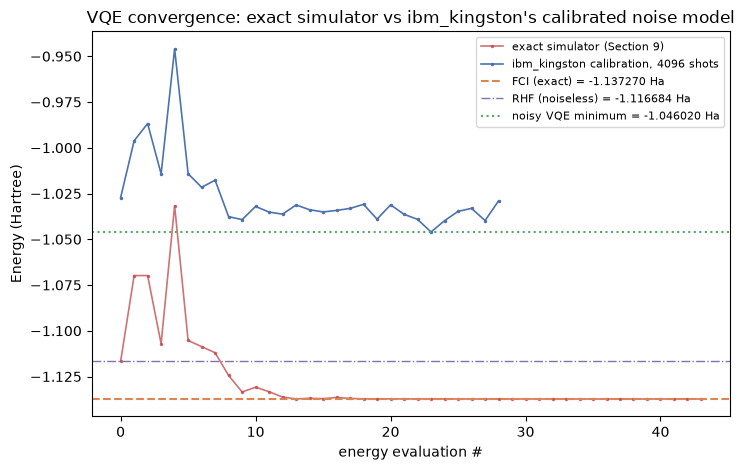

In [77]:

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(history_exact, lw=1.2, color='#C44E52', marker='.', ms=3, alpha=0.8,
        label='exact simulator (Section 9)')
ax.plot(history, lw=1.2, color='#4C72B0', marker='.', ms=3,
        label=f'{backend.name} calibration, {SHOTS} shots')
ax.axhline(e_fci, ls='--', color='#DD8452', label=f'FCI (exact) = {e_fci:.6f} Ha')
ax.axhline(mf.e_tot, ls='-.', color='#8172B3', lw=1,
           label=f'RHF (noiseless) = {mf.e_tot:.6f} Ha')
ax.axhline(result.fun, ls=':', color='#55A868', label=f'noisy VQE minimum = {result.fun:.6f} Ha')
ax.set_xlabel('energy evaluation #')
ax.set_ylabel('Energy (Hartree)')
ax.set_title("VQE convergence: exact simulator vs "
             f"{backend.name}'s calibrated noise model")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


In [78]:

print(f"{'':28s}{'energy (Ha)':>14s}  {'vs FCI':>12s}")
print(f"{'PySCF FCI (exact)':28s}{e_fci:14.6f}  {0.0:+12.6f}")
print(f"{'exact-simulator VQE':28s}{result_exact.fun:14.6f}  {result_exact.fun - e_fci:+12.6f}")
print(f"{'PySCF RHF (no correlation)':28s}{mf.e_tot:14.6f}  {mf.e_tot - e_fci:+12.6f}")
print(f"{backend.name + ' VQE':28s}{result.fun:14.6f}  {result.fun - e_fci:+12.6f}")
print()
print(f"the exact simulator recovers {100*(mf.e_tot - result_exact.fun)/(mf.e_tot - e_fci):.2f}%"
      f" of the correlation energy;")
print(f"the same ansatz and optimizer on {backend.name}'s noise recovers "
      f"{100*(mf.e_tot - result.fun)/(mf.e_tot - e_fci):.2f}%.")


                               energy (Ha)        vs FCI
PySCF FCI (exact)                -1.137270     +0.000000
exact-simulator VQE              -1.137270     +0.000000
PySCF RHF (no correlation)       -1.116684     +0.020586
ibm_kingston VQE                 -1.046020     +0.091250

the exact simulator recovers 100.00% of the correlation energy;
the same ansatz and optimizer on ibm_kingston's noise recovers -343.27%.


The comparison above is the whole point of the notebook. **Section 9's
exact run lands on FCI**; the identical ansatz and optimizer, evaluated
through a real device's calibration, lands far short -- typically worse
than plain Hartree-Fock, i.e. it recovers a *negative* fraction of the
correlation energy. Since the only thing that changed between the two runs
is how the energy is evaluated, everything lost in between is attributable
to the device, not to the algorithm. That is worth being precise about:

- **Transpilation is the dominant cost.** The logical circuit's 56 CX gates
  become ~43 physical CZ plus ~140 single-qubit gates once rewritten into
  the device's $R_z/\sqrt{X}/X$/CZ instruction set on a heavy-hex coupling
  map. The from-scratch Trotterized UCCSD circuit here was never optimized
  for depth, and on hardware that is what you pay for.
- **The error is a bias, not scatter.** Raising `SHOTS` shrinks the
  scatter in each evaluation as $1/\sqrt{N}$, but leaves the mean where it
  is. No amount of sampling recovers the correlation energy; that needs
  shallower circuits or error mitigation (ZNE, PEC, measurement-error
  mitigation), none of which is applied here.
- **Even $\theta=0$ is degraded.** The ansatz executes its full gate
  sequence regardless of the angle values, so the bare HF reference point
  is noisy too, not just the "interesting" parameter regions.
- **COBYLA is the wrong optimizer for this.** It was not designed for a
  noisy objective -- each evaluation now genuinely returns a different
  number at the same parameters (real shot noise, this time), which can
  shrink its trust region and stop it early. Section 9 deliberately uses
  the *same* optimizer on the exact energy so that this is a controlled
  comparison: COBYLA is clearly adequate there, so its struggles here are
  the noise's doing, not the optimizer's inherent weakness. NISQ-era work
  reaches for noise-aware optimizers such as SPSA for exactly this reason.

So the gap above is a fair picture of the mismatch between "the algorithm"
and "a real device," not something papered over.

Two independent fixes are worth trying, and this notebook tries both.
Section 11c keeps this exact circuit and swaps the optimizer for SPSA, to
see how much of the gap above is the optimizer's doing rather than the
circuit's. Section 12 then tries the complementary fix -- a shallower
ansatz -- with COBYLA still in the loop, so that the two fixes are never
conflated in a single run.

### 11c. UCCSD noisy VQE with a noise-aware optimizer (SPSA)

Section 11's diagnosis included the optimizer itself: COBYLA is a
trust-region method built for a deterministic objective, and a shot-noisy
energy evaluation -- returning a different number at the same parameters
every time -- can shrink that trust region and stop the search early.
**SPSA** (Simultaneous Perturbation Stochastic Approximation) was designed
for exactly this setting: instead of a finite-difference gradient (one
evaluation per parameter), it perturbs *all* parameters at once along a
single random $\pm1$ direction and estimates the whole gradient from just
two evaluations, regardless of dimension.

scipy's `optimize` module has no noise-aware optimizer to reach for here:
its local methods (COBYLA, Nelder-Mead, BFGS, ...) all assume a
deterministic objective, and its noise-tolerant global methods
(`differential_evolution`, `dual_annealing`) are population-based and need
far more evaluations per step than a 3-12 parameter circuit can afford
against a per-shot-costed backend. This notebook instead uses
`qiskit_algorithms.optimizers.SPSA` -- the standard SPSA implementation
used throughout the VQE literature, rather than a hand-tuned version of the
update rule. Its main advantage over rolling our own is **automatic
calibration**: left with `learning_rate=perturbation=None`, `SPSA.minimize`
runs a short calibration pass that measures the *actual* gradient
magnitude at the starting point and sets the step-size schedule from that,
rather than from guessed constants. (An earlier version of this notebook
implemented SPSA by hand with hand-picked step sizes and landed *worse*
than COBYLA in a single run -- consistent with badly calibrated step
sizes, not with SPSA being the wrong tool for the job.)

Same circuit (`qc_isa`), same observable (`observable_isa`), same
`noisy_estimator`, same backend and shot count as Section 11 -- only the
optimizer changes. Calibration itself costs additional energy evaluations
before the first real optimization step, which the evaluation count
printed below includes.

> **Prerequisite:** `pip install qiskit-algorithms` (see the setup
> instructions in the README).

In [79]:
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42   # reproducible SPSA perturbation directions

history_uccsd_spsa = []

def energy_spsa(theta):
    bound = qc_isa.assign_parameters(dict(zip(params, theta)))
    E = float(noisy_estimator.run([(bound, observable_isa)]).result()[0].data.evs)
    history_uccsd_spsa.append(E)
    return E

SPSA_MAXITER = 50   # matches Section 11's COBYLA budget in order of magnitude

spsa_uccsd = SPSA(maxiter=SPSA_MAXITER)   # learning_rate/perturbation left None -> auto-calibrated

t0 = time.time()
result_uccsd_spsa = spsa_uccsd.minimize(fun=energy_spsa, x0=np.zeros(len(params)))
elapsed_spsa = time.time() - t0

print(f"SPSA UCCSD VQE on {backend.name}: {SPSA_MAXITER} iterations "
      f"({len(history_uccsd_spsa)} energy evaluations -- includes automatic "
      f"step-size calibration, {elapsed_spsa:.0f}s)")
print(f"SPSA   minimum = {result_uccsd_spsa.fun:.6f} Ha   (gap vs FCI {result_uccsd_spsa.fun - e_fci:+.6f})")
print(f"COBYLA minimum = {result.fun:.6f} Ha   (gap vs FCI {result.fun - e_fci:+.6f})   [Section 11]")
print(f"FCI            = {e_fci:.6f} Ha")
print(f"RHF            = {mf.e_tot:.6f} Ha")

SPSA UCCSD VQE on ibm_kingston: 50 iterations (151 energy evaluations -- includes automatic step-size calibration, 462s)
SPSA   minimum = -1.028409 Ha   (gap vs FCI +0.108861)
COBYLA minimum = -1.046020 Ha   (gap vs FCI +0.091250)   [Section 11]
FCI            = -1.137270 Ha
RHF            = -1.116684 Ha


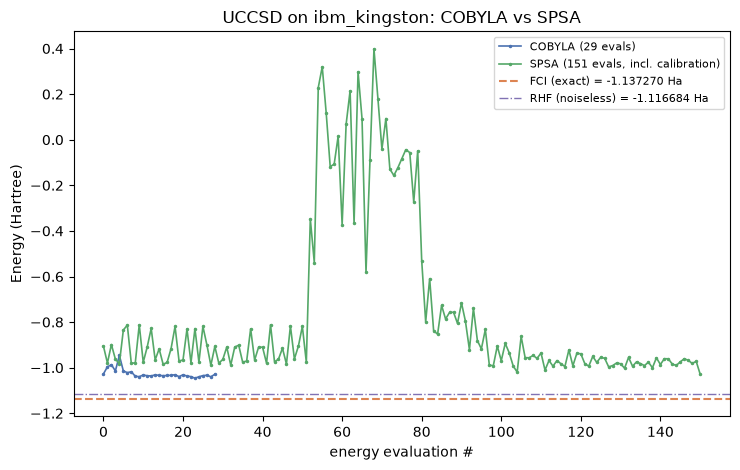

In [80]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(history, lw=1.2, color='#4C72B0', marker='.', ms=3,
        label=f'COBYLA ({len(history)} evals)')
ax.plot(history_uccsd_spsa, lw=1.2, color='#55A868', marker='.', ms=3,
        label=f'SPSA ({len(history_uccsd_spsa)} evals, incl. calibration)')
ax.axhline(e_fci, ls='--', color='#DD8452', label=f'FCI (exact) = {e_fci:.6f} Ha')
ax.axhline(mf.e_tot, ls='-.', color='#8172B3', lw=1,
           label=f'RHF (noiseless) = {mf.e_tot:.6f} Ha')
ax.set_xlabel('energy evaluation #')
ax.set_ylabel('Energy (Hartree)')
ax.set_title(f'UCCSD on {backend.name}: COBYLA vs SPSA')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

A single run of each optimizer cannot establish that SPSA is
systematically better here -- that would need repeated trials with
different seeds, the same caveat Section 12's ansatz comparison makes
explicit. What using the library's own implementation does remove is the
specific failure mode of an earlier, hand-rolled version of this section:
the step size is now set from a measured gradient magnitude rather than a
constant pulled out of the air. SPSA also cannot stop early the way
COBYLA sometimes does in Section 11 -- its evaluation budget is fixed
(iterations $\times$ 2, plus the one-time calibration cost) -- for better
or worse. Whether that converts into a lower energy on any given run is
still a matter of the specific noise realization drawn.


## 12. VQE with a hardware-efficient ansatz

Section 11's diagnosis was that UCCSD's *depth* is what the device cannot
afford. The standard response is a **hardware-efficient ansatz** (HEA):
stop deriving the circuit from chemistry, and instead build it from
whatever the hardware does cheaply. Here that means $n$ layers of
[$R_y$ on every qubit] followed by [a linear CNOT ladder], with one final
rotation layer:

$$|\psi(\vec\theta)\rangle = \Big[\textstyle\prod_{\ell}
  U_{\rm ent}\, R_y^{(\ell)}(\vec\theta_\ell)\Big] R_y^{(0)}(\vec\theta_0)
  |0\cdots0\rangle$$

What it buys and what it costs:

- **Buys depth.** No Trotterized Pauli-exponential blocks, no
  Jordan-Wigner $Z$-strings -- just rotations and nearest-neighbour
  entanglers, which is close to what the device already runs.
- **Costs physics.** The circuit encodes nothing about electrons. It does
  not conserve particle number or spin, and there is no guarantee the true
  ground state is even reachable.
- **Costs parameters.** UCCSD needed 3 angles for H$_2$; this needs
  $n_{\rm qubits}\times(n_{\rm layers}+1)$.

One reassurance specific to H$_2$/STO-3G: because the ansatz does not
conserve particle number, it can in principle wander into states with the
wrong electron count, and a variational minimum over the *full* Hilbert
space could in principle sit below the chemically meaningful answer. It
cannot here -- diagonalizing the full 16-dimensional Hamiltonian shows its
global ground state *is* the $N=2$ FCI state at $-1.13727$ Ha, with every
$N\neq2$ eigenvalue above it. For a general molecule that is not
guaranteed, and an unconstrained HEA can converge to a number that is
lower than FCI and physically meaningless.


            params   depth    CX   ->    ISA depth   CZ
UCCSD            3     110    56   ->          162   43
HEA L=2         12       8     6   ->           26    6



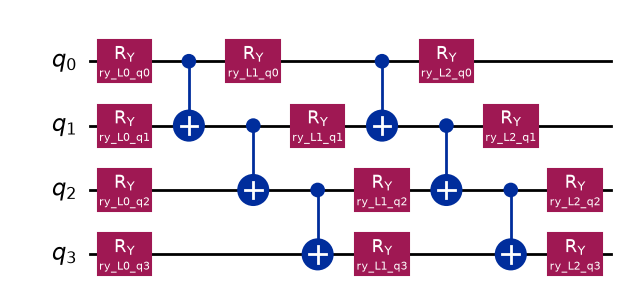

In [81]:

from qiskit.circuit import Parameter

def build_hardware_efficient_ansatz(n_qubits, n_layers):
    qc = QuantumCircuit(n_qubits, name='HardwareEfficient')
    ps = []

    def ry_layer(layer_idx):
        for q in range(n_qubits):
            t = Parameter(f"ry_L{layer_idx}_q{q}")
            ps.append(t)
            qc.ry(t, q)

    for layer in range(n_layers):
        ry_layer(layer)
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    ry_layer(n_layers)          # final rotation layer, no trailing entangler
    return qc, ps

HEA_LAYERS = 2
qc_hea, params_hea = build_hardware_efficient_ansatz(n_so, HEA_LAYERS)

qc_hea_isa = transpile(qc_hea, backend=sim, optimization_level=2, seed_transpiler=42)
observable_hea_isa = observable.apply_layout(qc_hea_isa.layout)

def counts(c):
    return {k: v for k, v in c.count_ops().items() if k != 'barrier'}

print(f"{'':10s}{'params':>8s}{'depth':>8s}{'CX':>6s}   ->   "
      f"{'ISA depth':>10s}{'CZ':>5s}")
print(f"{'UCCSD':10s}{len(params):>8d}{qc_uccsd.depth():>8d}"
      f"{counts(qc_uccsd).get('cx', 0):>6d}   ->   "
      f"{qc_isa.depth():>10d}{counts(qc_isa).get('cz', 0):>5d}")
print(f"{'HEA L=' + str(HEA_LAYERS):10s}{len(params_hea):>8d}{qc_hea.depth():>8d}"
      f"{counts(qc_hea).get('cx', 0):>6d}   ->   "
      f"{qc_hea_isa.depth():>10d}{counts(qc_hea_isa).get('cz', 0):>5d}")
print()
fig_hea = qc_hea.draw('mpl')
display(fig_hea)
plt.close(fig_hea)   # avoid a second, automatic render from the inline backend



### 12a. Exact HEA VQE, and the initialization problem

First on the exact simulator, to separate "can this ansatz represent the
ground state at all?" from "can it survive the device?". Since HEA has no
preferred starting point the way UCCSD does (where $\vec\theta=0$ *is* the
Hartree-Fock state), we try several, which exposes the ansatz's real
weakness.


In [82]:

def energy_hea_exact(theta, hist=None):
    bound = qc_hea.assign_parameters(dict(zip(params_hea, theta)))
    E = float(np.real(Statevector.from_instruction(bound).expectation_value(observable)))
    if hist is not None:
        hist.append(E)
    return E

starts = [("all zeros", np.zeros(len(params_hea)))]
for s in (0, 1, 7):
    starts.append((f"random (seed {s})",
                   np.random.default_rng(s).uniform(-np.pi, np.pi, len(params_hea))))

print(f"{'initial point':20s}{'E found (Ha)':>14s}{'vs FCI':>12s}{'evals':>8s}")
best = None
for tag, x0_hea in starts:
    h = []
    r = minimize(energy_hea_exact, x0_hea, args=(h,), method='COBYLA',
                 options={'maxiter': 2000, 'rhobeg': 0.5})
    verdict = "reaches FCI" if abs(r.fun - e_fci) < 1e-4 else "STUCK"
    print(f"{tag:20s}{r.fun:14.8f}{r.fun - e_fci:+12.2e}{len(h):8d}   {verdict}")
    if best is None or r.fun < best[0].fun:
        best = (r, h, tag)

result_hea_exact, history_hea_exact, best_tag = best
print(f"\nbest exact HEA run: {result_hea_exact.fun:.8f} Ha from '{best_tag}' "
      f"({len(history_hea_exact)} evaluations)")
print(f"UCCSD needed only {len(history_exact)} evaluations, from a single "
      f"obvious starting point.")


initial point         E found (Ha)      vs FCI   evals
all zeros              -1.13726983   +3.41e-07    2000   reaches FCI
random (seed 0)        -1.11844246   +1.88e-02    2000   STUCK
random (seed 1)        -1.13727007   +1.09e-07    2000   reaches FCI
random (seed 7)        -1.11668438   +2.06e-02     410   STUCK

best exact HEA run: -1.13727007 Ha from 'random (seed 1)' (2000 evaluations)
UCCSD needed only 44 evaluations, from a single obvious starting point.



This is the honest picture of a hardware-efficient ansatz. Some starting
points reach FCI; others stall, and the ones that stall often land almost
exactly on the *Hartree-Fock* energy -- the optimizer finds a
mean-field-quality state and cannot climb out. Even the successful runs
need on the order of a thousand evaluations against UCCSD's few dozen,
because there are four times as many parameters and none of them means
anything physically.

That cost is not incidental. It is the flip side of throwing away the
chemistry: UCCSD's 3 parameters came with a guarantee about *where* to
look, and a starting point that was already 98% of the answer.



### 12b. HEA on the real-device simulator

Now the comparison that matters: the same device, the same shot count, and
the **same optimizer budget** as the UCCSD run in Section 11, so the only
variable is the ansatz.


In [83]:

HEA_MAXITER = 100   # same budget as the UCCSD run in Section 11

history_hea = []

def energy_hea(theta):
    bound = qc_hea_isa.assign_parameters(dict(zip(params_hea, theta)))
    E = float(noisy_estimator.run([(bound, observable_hea_isa)]).result()[0].data.evs)
    history_hea.append(E)
    return E

t0 = time.time()
result_hea = minimize(energy_hea, np.zeros(len(params_hea)), method='COBYLA',
                      options={'maxiter': HEA_MAXITER, 'rhobeg': 0.5})
elapsed_hea = time.time() - t0

print(f"noisy HEA VQE on {backend.name}: {len(history_hea)} evaluations "
      f"({elapsed_hea:.0f}s, {elapsed_hea/len(history_hea):.1f}s each)")
print(f"HEA   minimum = {result_hea.fun:.6f} Ha   (gap vs FCI {result_hea.fun - e_fci:+.6f})")
print(f"UCCSD minimum = {result.fun:.6f} Ha   (gap vs FCI {result.fun - e_fci:+.6f})")
print(f"FCI           = {e_fci:.6f} Ha")
print(f"RHF           = {mf.e_tot:.6f} Ha")


noisy HEA VQE on ibm_kingston: 100 evaluations (306s, 3.1s each)
HEA   minimum = -1.056117 Ha   (gap vs FCI +0.081153)
UCCSD minimum = -1.046020 Ha   (gap vs FCI +0.091250)
FCI           = -1.137270 Ha
RHF           = -1.116684 Ha


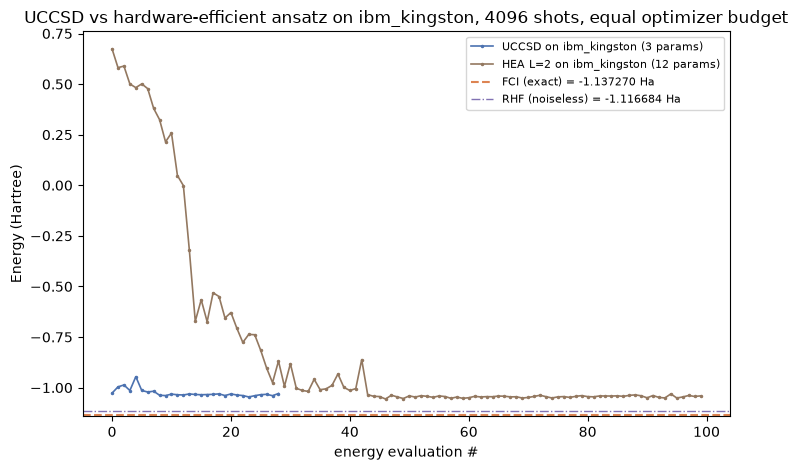

In [84]:

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(history, lw=1.2, color='#4C72B0', marker='.', ms=3,
        label=f'UCCSD on {backend.name} ({len(params)} params)')
ax.plot(history_hea, lw=1.2, color='#937860', marker='.', ms=3,
        label=f'HEA L={HEA_LAYERS} on {backend.name} ({len(params_hea)} params)')
ax.axhline(e_fci, ls='--', color='#DD8452', label=f'FCI (exact) = {e_fci:.6f} Ha')
ax.axhline(mf.e_tot, ls='-.', color='#8172B3', lw=1,
           label=f'RHF (noiseless) = {mf.e_tot:.6f} Ha')
ax.set_xlabel('energy evaluation #')
ax.set_ylabel('Energy (Hartree)')
ax.set_title(f'UCCSD vs hardware-efficient ansatz on {backend.name}, '
             f'{SHOTS} shots, equal optimizer budget')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


In [85]:

rows = [
    ("UCCSD",  "exact",         result_exact.fun,     len(params),     len(history_exact)),
    ("UCCSD",  backend.name,    result.fun,           len(params),     len(history)),
    ("HEA",    "exact (best)",  result_hea_exact.fun, len(params_hea), len(history_hea_exact)),
    ("HEA",    backend.name,    result_hea.fun,       len(params_hea), len(history_hea)),
]
print(f"{'ansatz':8s}{'evaluated on':16s}{'E (Ha)':>12s}{'vs FCI':>11s}"
      f"{'params':>8s}{'evals':>8s}")
for a, where, E, npar, nev in rows:
    print(f"{a:8s}{where:16s}{E:12.6f}{E - e_fci:+11.6f}{npar:8d}{nev:8d}")
print(f"\n{'FCI (exact)':24s}{e_fci:12.6f}")
print(f"{'RHF (noiseless)':24s}{mf.e_tot:12.6f}")


ansatz  evaluated on          E (Ha)     vs FCI  params   evals
UCCSD   exact              -1.137270  +0.000000       3      44
UCCSD   ibm_kingston       -1.046020  +0.091250       3      29
HEA     exact (best)       -1.137270  +0.000000      12    2000
HEA     ibm_kingston       -1.056117  +0.081153      12     100

FCI (exact)                -1.137270
RHF (noiseless)            -1.116684


**This run does not determine which ansatz is better.** HEA may well come
out ahead in the table above, and that is the direction the depth argument
predicts. But a single pair of stochastic runs cannot support a ranking.
An earlier version of this notebook picked the backend with
`least_busy(...)`, and the same HEA cell, with the same settings, returned
$-0.968$ Ha on one visit and $-1.084$ Ha on another purely because a
different device was selected each time -- a $0.116$ Ha spread that is
roughly twice the gap between the two ansätze in any one run. That is why
Section 10 now pins an explicit backend (`ibm_kingston`): it removes device
identity as a source of variation, so every comparison in this notebook is
at least evaluated against a single, nameable calibration snapshot.

Even with a fixed backend, several things still resample every time this
notebook runs:

- Calibration drifts from day to day even on a single machine, so
  re-running this notebook next week measures a nearby but different noise
  profile.
- Shot noise gives COBYLA a different trajectory, and so a different local
  minimum.
- **Where COBYLA stops is itself stochastic.** Both runs are capped at the
  same number of evaluations, but the UCCSD run often terminates far
  early -- its trust region collapses against the noisy objective, the
  failure mode Section 11 describes. That stopping point is not
  reproducible, and on its own it can swing the comparison.

What does *not* resample, and is therefore worth stating plainly:

- HEA's transpiled circuit is ~6x shallower with ~7x fewer two-qubit
  gates. That is a measured property of the circuits, not of any run.
- HEA pays for it with 12 unstructured parameters against UCCSD's 3, and
  Section 12a showed it needs on the order of a thousand evaluations to
  converge even against a *perfect* energy oracle.
- The starting points are not comparable: $\vec\theta=0$ is the
  Hartree-Fock state for UCCSD (0.02 Ha from the answer) but the vacuum
  $|0000\rangle$ for HEA (~1.8 Ha away, with the wrong electron count).
- **Neither ansatz beats Hartree-Fock.** RHF sits at $-1.1167$ Ha; both
  device results land above it, recovering *negative* correlation energy.
  This is the one conclusion robust enough to lean on.

So the section demonstrates a real trade -- a large depth reduction bought
with parameter count and trainability -- without resolving it. Resolving it
would need budgets scaled to parameter count, HEA started from a
correct-particle-number state, and enough repeats to put error bars on
each configuration. The cleanest single experiment skips the optimizer
entirely: measure the *bias* of both circuits at one fixed parameter point,
repeated. That isolates depth with nothing else moving.

Worth experimenting with: raise `HEA_MAXITER` to give the 12 parameters a
fair chance (at roughly 2.5 s per evaluation, 500 iterations is about 20
minutes), or drop `HEA_LAYERS` to 1 for 8 parameters and a depth-5 circuit.
Section 12c tries the other lever explored in Section 11c: keeping this
ansatz and backend fixed, but swapping COBYLA for SPSA.

### 12c. HEA noisy VQE with SPSA

Same swap as Section 11c, applied to the hardware-efficient ansatz: keep
the circuit (`qc_hea_isa`), observable (`observable_hea_isa`), backend and
shot count from Section 12b fixed, and construct a fresh
`qiskit_algorithms.optimizers.SPSA` instance -- calibration is specific to
the loss landscape at hand, so it is not reused across ansätze. HEA has
four times as many parameters as UCCSD (12 vs. 3), but SPSA's
per-iteration cost does not grow with parameter count -- still two
evaluations per step -- so the optimization budget below stays directly
comparable to Section 11c's, unlike COBYLA's, whose cost per iteration
does scale with dimension.

Before spending real-backend time on this, it is worth checking on the
exact simulator -- the same technique Section 12a used for COBYLA --
whether the all-zeros starting point is actually a good one for SPSA. It
gets used again below for a fair, apples-to-apples comparison with Section
12b's COBYLA run (same ansatz, same starting point, only the optimizer
changes) -- but "fair" is not the same as "good." SPSA's gradient estimate
at every step comes from perturbing *all* parameters at once along a
single random direction, and at $\vec\theta=0$ the HEA circuit sits at a
highly symmetric point (every $R_y$ is the identity). There is no
guarantee that probing the landscape that way behaves anything like
COBYLA's local quadratic model did from the same point.

In [86]:
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42   # reproducible SPSA perturbation directions

diag_starts = [("all zeros", np.zeros(len(params_hea)))]
for s in (0, 1, 7):
    diag_starts.append((f"random (seed {s})",
                        np.random.default_rng(s).uniform(-np.pi, np.pi, len(params_hea))))

print(f"{'initial point':20s}{'maxiter':>8s}{'E found (Ha)':>14s}{'vs FCI':>12s}{'verdict':>14s}")
for tag, x0_diag in diag_starts:
    for maxiter_diag in (50, 500):
        spsa_diag = SPSA(maxiter=maxiter_diag)
        r_diag = spsa_diag.minimize(fun=energy_hea_exact, x0=x0_diag)
        verdict = "reaches FCI" if abs(r_diag.fun - e_fci) < 1e-4 else "STUCK"
        print(f"{tag:20s}{maxiter_diag:8d}{r_diag.fun:14.8f}{r_diag.fun - e_fci:+12.2e}{verdict:>14s}")

initial point        maxiter  E found (Ha)      vs FCI       verdict
all zeros                 50   -0.24705108   +8.90e-01         STUCK
all zeros                500   -0.94040886   +1.97e-01         STUCK
random (seed 0)           50   -1.09924901   +3.80e-02         STUCK
random (seed 0)          500   -1.11643402   +2.08e-02         STUCK
random (seed 1)           50   -1.00724415   +1.30e-01         STUCK
random (seed 1)          500   -1.13686313   +4.07e-04         STUCK
random (seed 7)           50   -0.90161498   +2.36e-01         STUCK
random (seed 7)          500   -1.11645321   +2.08e-02         STUCK


All-zeros is a poor starting point for SPSA here, in a way it was not for
COBYLA: Section 12a's table showed all-zeros reaching FCI for COBYLA in
2000 evaluations, while here it is the *worst* of the four starting points
for SPSA by a wide margin. It does improve substantially with more
iterations -- from a gap of $+0.89$ Ha at 50 iterations down to $+0.20$ Ha
at 500 -- but even at $10\times$ the budget it remains roughly **ten
times** farther from FCI than any of the random starts get at the same
budget ($+0.021$, $+0.0004$, and $+0.021$ Ha for seeds 0, 1, and 7). Seed 1
in particular has essentially reached FCI by 500 iterations. That is the
opposite ranking from Section 12a's COBYLA table, where the random starts
were the ones that got stuck and all-zeros reached FCI outright.

The noisy run below deliberately keeps the all-zeros starting point
anyway, for the same reason Section 12b did: changing more than one thing
at a time (optimizer *and* starting point) would make it impossible to say
which change caused any difference in the result. But that means the
noisy SPSA result below should be read as **a starting-point/landscape
mismatch at least as much as a noise effect** -- and the all-zeros,
50-iteration row above ($+0.89$ Ha) gives a concrete number to check that
against: if the noisy result lands close to it, noise is not the dominant
story.

In [87]:
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42   # reproducible SPSA perturbation directions

history_hea_spsa = []

def energy_hea_spsa(theta):
    bound = qc_hea_isa.assign_parameters(dict(zip(params_hea, theta)))
    E = float(noisy_estimator.run([(bound, observable_hea_isa)]).result()[0].data.evs)
    history_hea_spsa.append(E)
    return E

HEA_SPSA_MAXITER = 50   # same iteration budget as Section 11c

spsa_hea = SPSA(maxiter=HEA_SPSA_MAXITER)   # fresh instance -> its own calibration pass

t0 = time.time()
result_hea_spsa = spsa_hea.minimize(fun=energy_hea_spsa, x0=np.zeros(len(params_hea)))
elapsed_hea_spsa = time.time() - t0

print(f"SPSA HEA VQE on {backend.name}: {HEA_SPSA_MAXITER} iterations "
      f"({len(history_hea_spsa)} energy evaluations -- includes automatic "
      f"step-size calibration, {elapsed_hea_spsa:.0f}s)")
print(f"SPSA   minimum = {result_hea_spsa.fun:.6f} Ha   (gap vs FCI {result_hea_spsa.fun - e_fci:+.6f})")
print(f"COBYLA minimum = {result_hea.fun:.6f} Ha   (gap vs FCI {result_hea.fun - e_fci:+.6f})   [Section 12b]")
print(f"FCI            = {e_fci:.6f} Ha")
print(f"RHF            = {mf.e_tot:.6f} Ha")

SPSA HEA VQE on ibm_kingston: 50 iterations (151 energy evaluations -- includes automatic step-size calibration, 457s)
SPSA   minimum = -0.273717 Ha   (gap vs FCI +0.863554)
COBYLA minimum = -1.056117 Ha   (gap vs FCI +0.081153)   [Section 12b]
FCI            = -1.137270 Ha
RHF            = -1.116684 Ha


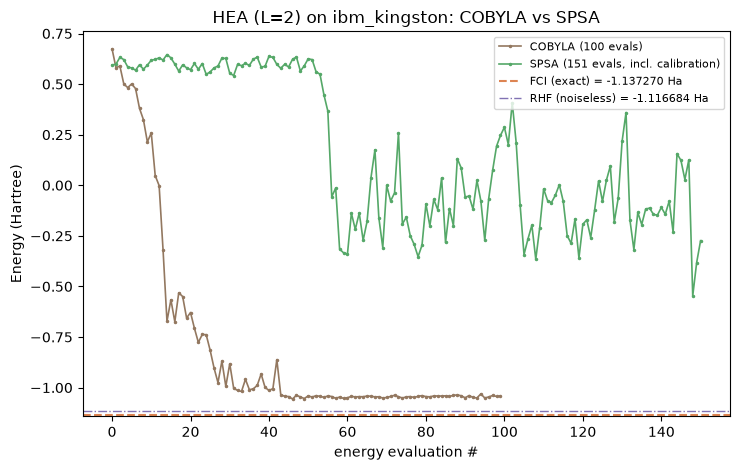


ansatz  optimizer       E (Ha)     vs FCI  params   evals
UCCSD   COBYLA       -1.046020  +0.091250       3      29
UCCSD   SPSA         -1.028409  +0.108861       3     151
HEA     COBYLA       -1.056117  +0.081153      12     100
HEA     SPSA         -0.273717  +0.863554      12     151

FCI (exact)            -1.137270
RHF (noiseless)        -1.116684

all four rows above use the same backend (ibm_kingston) and shot count (4096); only ansatz and optimizer vary. SPSA's evals include its one-time calibration pass.


In [88]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(history_hea, lw=1.2, color='#937860', marker='.', ms=3,
        label=f'COBYLA ({len(history_hea)} evals)')
ax.plot(history_hea_spsa, lw=1.2, color='#55A868', marker='.', ms=3,
        label=f'SPSA ({len(history_hea_spsa)} evals, incl. calibration)')
ax.axhline(e_fci, ls='--', color='#DD8452', label=f'FCI (exact) = {e_fci:.6f} Ha')
ax.axhline(mf.e_tot, ls='-.', color='#8172B3', lw=1,
           label=f'RHF (noiseless) = {mf.e_tot:.6f} Ha')
ax.set_xlabel('energy evaluation #')
ax.set_ylabel('Energy (Hartree)')
ax.set_title(f'HEA (L={HEA_LAYERS}) on {backend.name}: COBYLA vs SPSA')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

rows_opt = [
    ("UCCSD", "COBYLA", result.fun,             len(params),     len(history)),
    ("UCCSD", "SPSA",   result_uccsd_spsa.fun,   len(params),     len(history_uccsd_spsa)),
    ("HEA",   "COBYLA", result_hea.fun,          len(params_hea), len(history_hea)),
    ("HEA",   "SPSA",   result_hea_spsa.fun,     len(params_hea), len(history_hea_spsa)),
]
print(f"\n{'ansatz':8s}{'optimizer':10s}{'E (Ha)':>12s}{'vs FCI':>11s}{'params':>8s}{'evals':>8s}")
for a, opt, E, npar, nev in rows_opt:
    print(f"{a:8s}{opt:10s}{E:12.6f}{E - e_fci:+11.6f}{npar:8d}{nev:8d}")
print(f"\n{'FCI (exact)':20s}{e_fci:12.6f}")
print(f"{'RHF (noiseless)':20s}{mf.e_tot:12.6f}")
print(f"\nall four rows above use the same backend ({backend.name}) and shot "
      f"count ({SHOTS}); only ansatz and optimizer vary. SPSA's evals "
      f"include its one-time calibration pass.")

As in Section 11c, this single run cannot crown SPSA the better optimizer
-- both algorithms are being evaluated on one noise realization each, on a
backend that is now at least held fixed. Unlike Section 11c's UCCSD
comparison, though, this one is not primarily a noise story: the noisy run
above landed at a gap of $+0.86$ Ha, and the exact-simulator diagnostic
earlier in this section already found $+0.89$ Ha from the same all-zeros
starting point at the same 50-iteration budget -- with **zero** noise. The
two numbers are close enough that shot noise is clearly not what drives
this result; a bad starting point for this optimizer, on this ansatz, is.
That is a genuine finding about SPSA and this ansatz's landscape, not an
artifact of shot noise or of hand-rolled code --
`qiskit_algorithms.optimizers.SPSA` produces it too. What the four-row
table above still makes easy to see is that ansatz and optimizer are
independent choices: this notebook has now varied each one while holding
the other fixed, and for HEA specifically, the choice of *starting point*
turns out to matter at least as much as either.

## Summary

This notebook explored $\textrm{H}_2$ ground-state VQE along three
independent axes -- **ansatz** (UCCSD vs. hardware-efficient), **energy
evaluation** (exact vs. a real device's noise), and **optimizer** (COBYLA
vs. SPSA) -- changing one at a time so each comparison isolates a single
cause:

- Built $\textrm{H}_2$'s **UCCSD** ansatz circuit from scratch (integrals →
  qubit Hamiltonian → excitation operators → Pauli-exponential circuit
  blocks → full ansatz), same pipeline and block-spin/Qiskit-matching
  conventions as `H2_UCCSD_from_scratch.ipynb`, with no intermediate
  verification cells.
- Ran VQE first against an **exact** energy evaluation
  (`Statevector.expectation_value` -- no sampling, no noise) to establish
  the noiseless baseline: UCCSD recovers essentially all of
  $\textrm{H}_2$'s correlation energy, and the single-excitation angles go
  to zero as Brillouin's theorem requires.
- Built the **noisy simulator** from a **real IBM backend's live
  calibration** (`AerSimulator.from_backend`) instead of hand-picked
  depolarizing rates: per-qubit $T_1$/$T_2$, per-gate errors, per-qubit
  readout confusion, heavy-hex coupling map and native ISA, all in one
  call. Only calibration data is downloaded; nothing is submitted to
  hardware. The backend is a **fixed, explicitly named device**
  (`ibm_kingston`), not `least_busy(...)`, so that every run in the
  notebook is measured against the same calibration snapshot and the
  comparisons stay meaningful.
- Transpiled the ansatz into the device's $R_z/\sqrt{X}/X$/CZ instruction
  set and re-mapped the observable through the resulting layout -- the
  step where a from-scratch UCCSD circuit really pays for its depth.
- Used `qiskit.primitives.BackendEstimatorV2` with an **explicit shot
  count**, so every noisy energy is reconstructed from actual bitstring
  counts after real basis rotations. (Aer's own `EstimatorV2`, used
  earlier, never samples: it computes the exact expectation value and
  adds a synthetic Gaussian, and ignores `shots` entirely.)
- Ran the *same* closed-loop VQE (same ansatz, same optimizer, same
  starting point) against the device's noise. Because only the energy
  evaluation changed between the exact and noisy UCCSD runs, the
  difference between them isolates the cost of the hardware. That
  remaining gap is a *bias*, not sampling scatter -- the distinction that
  matters when deciding whether to buy more shots or reach for error
  mitigation.
- Tried the **hardware-efficient ansatz**, roughly six times shallower
  after transpilation. It can land closer to FCI on the device, but that
  ordering is not reproducible run-to-run: COBYLA's stopping point moves,
  and calibration drifts. The durable findings are that HEA buys a large
  depth reduction at the cost of 12 unstructured parameters and much
  harder optimization (~1000 evaluations even against a perfect energy
  oracle, with several initial points stalling at the Hartree-Fock
  energy), and that **neither ansatz reliably beats Hartree-Fock on the
  device**.
- Tried **`qiskit_algorithms.optimizers.SPSA`** in place of COBYLA, for
  both ansätze, on the same fixed backend and shot count. SPSA estimates a
  full gradient from two evaluations regardless of parameter count, so its
  evaluation budget cannot be cut short by a collapsing trust region the
  way COBYLA's can; using the library's own implementation, rather than a
  hand-rolled version with guessed step sizes, also gets automatic
  calibration of the step-size schedule from a measured gradient
  magnitude, at the cost of extra evaluations up front. For UCCSD, SPSA
  and COBYLA landed within noise of each other. For HEA, SPSA did
  dramatically *worse* than COBYLA -- and an exact-simulator diagnostic
  (Section 12c) showed why: the all-zeros starting point, kept for a fair
  comparison with COBYLA, is actually a bad one for SPSA specifically.
  SPSA got stuck there even with **zero noise**, so the noisy-backend gap
  is mostly a starting-point/landscape mismatch, not a shot-noise effect
  -- a genuine property of SPSA on this ansatz, not an artifact of noise
  or of hand-rolled code.
- Varying ansatz and optimizer one at a time, rather than together, kept
  these two independent levers -- circuit depth and optimizer robustness
  to noise and initialization -- from being conflated in a single number,
  and surfaced a result (SPSA's HEA failure) that a single combined
  experiment would have hidden.
- **What this notebook cannot show:** every noisy result above comes from
  `AerSimulator.from_backend`, which replays one *fixed* calibration
  snapshot pulled from a real device -- it is a model of the device, not
  the device. Error-mitigation techniques such as zero-noise extrapolation
  (ZNE), probabilistic error cancellation (PEC), and measurement-error
  mitigation work by deliberately intervening in how a circuit executes on
  actual hardware (stretching or folding gates to extrapolate to zero
  noise, inverting a live-calibrated readout confusion matrix, averaging
  over runs against the device's real, moment-to-moment drift) or by
  spending extra real shots and circuit variants to characterize and
  cancel a *live* error channel. None of that has anything to act on
  against a single static noise channel replayed identically every time,
  so this notebook cannot show whether mitigation would close the gaps
  reported above -- only a submission to the real backend, which this
  notebook deliberately never does, could answer that.